In [1]:
from google.colab import files
uploaded = files.upload()

Saving LegitReachResearchD2CDataFashionAndApparel.csv to LegitReachResearchD2CDataFashionAndApparel.csv


In [2]:
import io, os
import pandas as pd # Import pandas

if uploaded:
    filename = list(uploaded.keys())[0]
    print("Using uploaded file:", filename)
    # try to infer CSV/Excel
    if filename.lower().endswith(('.xls', '.xlsx')):
        df = pd.read_excel(io.BytesIO(uploaded[filename]))
    else:
        df = pd.read_csv(io.BytesIO(uploaded[filename]))

Using uploaded file: LegitReachResearchD2CDataFashionAndApparel.csv


In [3]:
print("Dataset loaded. Basic info:")
print("Rows, Columns:", df.shape)
print("\nColumn names:")
print(list(df.columns))
print("\nFirst 5 rows:")
display(df.head())

Dataset loaded. Basic info:
Rows, Columns: (14288, 43)

Column names:
['website', 'company', 'country', 'state', 'platform', 'technology_spend', 'sales_revenue', 'estimated_visits', 'website_created_at', 'emails', 'telephones', 'vertical', 'employees', 'product_page_count', 'variant_count', 'average_product_price', 'theme', 'currency', 'language', 'appsInstalled', 'technology', 'x', 'twitter', 'tiktok', 'facebook', 'linkedin', 'pinterest', 'instagram', 'youtube', 'vimeo', 'whatsapp', 'yelp', 'Snapchat', 'total_affected_elements', 'total_violation_types', 'severity_critical', 'severity_serious', 'severity_moderate', 'severity_minor', 'contrast_errors', 'aria_errors', 'accessibility_errors', 'total_errors']

First 5 rows:


,website,company,country,state,platform,technology_spend,sales_revenue,estimated_visits,website_created_at,emails,...,total_affected_elements,total_violation_types,severity_critical,severity_serious,severity_moderate,severity_minor,contrast_errors,aria_errors,accessibility_errors,total_errors
0,intl.nykaafashion.com,Nykaa Fashion Ltd,US,NaN,Shopify,153.97,837258,73117.0,2023-01-27T19:12:27,"support@nykaafashion.com, grievanceofficer@nyk...",...,13.0,4.0,5.0,8.0,0.0,0.0,5.0,0.0,8.0,13.0
1,merch.sixflags.com,Six Flags Entertainment Corporation,US,TX,Shopify,123.17,639915,47933.0,2021-03-03T19:02:06,"copyrightagent@sixflags.com, sixflags@wearsthe...",...,6.0,2.0,5.0,1.0,0.0,0.0,5.0,0.0,1.0,6.0
2,usastore.thebeatles.com,Apple Corps Ltd,US,NaN,Shopify,381.97,1061528,90631.0,2020-08-30T13:29:12,"privacy.officer@umusic.com, thebeatles@umgstor...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,shop.atlantamagazine.com,Atlanta Magazine,US,GA,Shopify,133.48,5118,0.0,2023-11-30T11:06:47,"mbikoff@atlantamagazine.com, trehagen@atlantam...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,shop.thelibertydaily.com,The Liberty Daily,US,PA,Shopify,214.90,90758,5502.0,2021-03-19T21:02:51,"paul@theprb.co, thelibertydaily@gmail.com",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
social_cols = ['twitter','tiktok','facebook','linkedin','pinterest','instagram','youtube','vimeo','whatsapp','yelp','Snapchat']

In [22]:
available_social = [c for c in social_cols if c in df.columns]
print("Social media columns found:", available_social)

Social media columns found: ['twitter', 'tiktok', 'facebook', 'linkedin', 'pinterest', 'instagram', 'youtube']


In [20]:
missing_social = (
    df[available_social].isna().mean().sort_values(ascending=False) * 100
)

In [21]:
print("\nMissing percentages (Week 1 requirement):")
display(missing_social.to_frame("missing_%"))


Missing percentages (Week 1 requirement):


,missing_%
linkedin,95.583707
youtube,89.438690
pinterest,84.021557
twitter,83.265677
tiktok,80.893057
facebook,29.906215
instagram,12.283035


In [23]:
# --- BLOCK 2: Clean URLs for Social Handles ---

def clean_url(url):
    if pd.isna(url) or str(url).strip().lower() in ['nan', '', 'none']:
        return None

    url = str(url).strip()

    # Remove spaces and trailing slashes
    url = url.replace(" ", "").rstrip("/")

    # Ensure url starts with https
    if not url.startswith("http"):
        url = "https://" + url

    # Basic fix for missing domain types
    if "instagram.com" in url and "https://" not in url:
        url = "https://" + url

    if "linkedin.com" in url and "https://" not in url:
        url = "https://" + url

    if "facebook.com" in url and "https://" not in url:
        url = "https://" + url

    return url

# Re-evaluate available_social to reflect columns currently in df
available_social = [c for c in social_cols if c in df.columns]

# Apply cleaning
for col in available_social:
    df[col] = df[col].apply(clean_url)

print("URL cleaning complete.")
df[available_social].head(10)

URL cleaning complete.


,twitter,tiktok,facebook,linkedin,pinterest,instagram,youtube
0,https://twitter.com/nykaafashion,None,https://facebook.com/nykaafashion,None,https://pinterest.com/nykaafashion,https://instagram.com/nykaafashion,None
1,https://twitter.com/sixflags,None,https://facebook.com/sixflags,https://linkedin.com/company/six-flags,None,None,None
2,https://twitter.com/thebeatles,None,https://facebook.com/beatles,None,None,https://instagram.com/thebeatles,https://www.youtube.com/channel/UCc4K7bAqpdBP8...
3,https://twitter.com/atlantamagazine,None,https://facebook.com/atlantamag,https://linkedin.com/company/atlantamagazine,None,https://instagram.com/atlantamagazine,None
4,None,None,None,None,None,None,None
5,https://twitter.com/silbonmoda,https://tiktok.com/@silbonmoda,https://facebook.com/silbonmoda,https://linkedin.com/company/silbon,None,https://instagram.com/silbonmoda,https://youtube.com/user/silbonmoda
6,https://twitter.com/alamodelabel,None,https://facebook.com/a.la.modebyakanksha,None,https://pinterest.com/alamodebyakanksha,https://instagram.com/a.la.modebyakanksha,None
7,None,None,None,https://linkedin.com/company/coldculture,None,https://instagram.com/coldculture,None
8,https://twitter.com/insightglobal,None,https://facebook.com/insightgloballlc,https://linkedin.com/company/insight-global,None,https://instagram.com/insight_global,None
9,None,None,None,None,None,None,None


In [29]:
# --- BLOCK 3: Binary Encoding (Active / Inactive) ---

for col in available_social:
    df[col + "_active"] = df[col].notna().astype(int)

active_cols = [c + "_active" for c in available_social]

df[active_cols].head()


,twitter_active,tiktok_active,facebook_active,linkedin_active,pinterest_active,instagram_active,youtube_active
0,1,0,1,0,1,1,0
1,1,0,1,1,0,0,0
2,1,0,1,0,0,1,1
3,1,0,1,1,0,1,0
4,0,0,0,0,0,0,0


In [28]:
# --- BLOCK 4: Active Platform Count & Social Presence Index ---

# Week 1: total number of active platforms per brand
df["active_platform_count"] = df[active_cols].sum(axis=1)

# Week 2: Social Presence Index (SPI = Active / 8 platforms)
SPI_MAX = 7   # based on official doc
df["SPI"] = df["active_platform_count"] / SPI_MAX

# Clip SPI between [0,1]
df["SPI"] = df["SPI"].clip(0, 1)

df[["active_platform_count", "SPI"]].head()


,active_platform_count,SPI
0,4,0.571429
1,3,0.428571
2,4,0.571429
3,4,0.571429
4,0,0.000000


In [30]:
# --- BLOCK 5: Engagement Score (Weighted Social Media Activity) ---

weights = {
    'instagram_active': 0.30,
    'tiktok_active': 0.25,
    'youtube_active': 0.20,
    'linkedin_active': 0.10,
    'facebook_active': 0.10,
    'twitter_active': 0.03,
    'pinterest_active': 0.02
}

df['engagement_score'] = 0

for col, w in weights.items():
    if col in df.columns:
        df['engagement_score'] += df[col] * w

df['engagement_score'] = df['engagement_score'].round(3)

df[['SPI', 'active_platform_count', 'engagement_score']].head()


,SPI,active_platform_count,engagement_score
0,0.571429,4,0.45
1,0.428571,3,0.23
2,0.571429,4,0.63
3,0.571429,4,0.53
4,0.000000,0,0.00


In [32]:
# --- BLOCK 6: Social Strength Score (Advanced Feature) ---

import numpy as np

df['social_strength'] = df['SPI'] * np.log1p(df['engagement_score'] * 10)
df['social_strength'] = df['social_strength'].round(3)

df[['SPI', 'engagement_score', 'social_strength']].head()

,SPI,engagement_score,social_strength
0,0.571429,0.45,0.974
1,0.428571,0.23,0.512
2,0.571429,0.63,1.136
3,0.571429,0.53,1.052
4,0.000000,0.00,0.000


In [33]:
# --- BLOCK 7: Social Diversification Buckets ---

def diversification_bucket(n):
    if n == 0:
        return "No Presence"
    elif n <= 2:
        return "Low"
    elif n <= 4:
        return "Medium"
    else:
        return "High"

df['diversification_bucket'] = df['active_platform_count'].apply(diversification_bucket)

df['diversification_bucket'].value_counts()


,count
diversification_bucket,
Low,7508
Medium,4848
No Presence,1314
High,618


In [38]:
# --- BLOCK 8: Interaction Features for Social Media Synergy ---

# Core interactions
interaction_pairs = [
    ('instagram_active', 'tiktok_active'),
    ('instagram_active', 'youtube_active'),
    ('tiktok_active', 'youtube_active'),
    ('instagram_active', 'linkedin_active')
]

for a, b in interaction_pairs:
    if a in df.columns and b in df.columns:
        df[f"{a}_{b}_interaction"] = df[a] * df[b]

df.head(2)


,website,company,country,state,platform,technology_spend,sales_revenue,estimated_visits,website_created_at,emails,...,engagement_score,social_strength,diversification_bucket,instagram_active_tiktok_active_interaction,instagram_active_youtube_active_interaction,tiktok_active_youtube_active_interaction,instagram_active_linkedin_active_interaction,SPI_norm,engagement_norm,social_strength_norm
0,intl.nykaafashion.com,Nykaa Fashion Ltd,US,NaN,Shopify,153.97,837258,73117.0,2023-01-27T19:12:27,"support@nykaafashion.com, grievanceofficer@nyk...",...,0.45,0.974,Medium,0,0,0,0,0.571429,0.45,0.406172
1,merch.sixflags.com,Six Flags Entertainment Corporation,US,TX,Shopify,123.17,639915,47933.0,2021-03-03T19:02:06,"copyrightagent@sixflags.com, sixflags@wearsthe...",...,0.23,0.512,Medium,0,0,0,0,0.428571,0.23,0.213511


In [39]:
# --- BLOCK 9: Social Platform Co-occurrence Matrix ---

co_matrix = df[[c for c in df.columns if c.endswith('_active')]].T.dot(
    df[[c for c in df.columns if c.endswith('_active')]]
)

co_matrix.head(2)


,twitter_active,tiktok_active,facebook_active,linkedin_active,pinterest_active,instagram_active,youtube_active
twitter_active,2391,613,2112,249,724,2315,527
tiktok_active,613,2730,2128,137,735,2696,384


In [36]:
# --- BLOCK 10: Normalize SPI, engagement_score, social_strength ---

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['SPI_norm', 'engagement_norm', 'social_strength_norm']] = scaler.fit_transform(
    df[['SPI', 'engagement_score', 'social_strength']]
)

df[['SPI_norm', 'engagement_norm', 'social_strength_norm']].head()


,SPI_norm,engagement_norm,social_strength_norm
0,0.571429,0.45,0.406172
1,0.428571,0.23,0.213511
2,0.571429,0.63,0.473728
3,0.571429,0.53,0.438699
4,0.000000,0.00,0.000000


In [37]:
# --- BLOCK 11: Week 2 Summary ---

week2_summary = df[['SPI','engagement_score','social_strength',
                    'diversification_bucket',
                    'SPI_norm', 'engagement_norm', 'social_strength_norm']]

week2_summary.describe(include='all')


,SPI,engagement_score,social_strength,diversification_bucket,SPI_norm,engagement_norm,social_strength_norm
count,14288.000000,14288.000000,14288.000000,14288,14288.000000,14288.000000,14288.000000
unique,NaN,NaN,NaN,4,NaN,NaN,NaN
top,NaN,NaN,NaN,Low,NaN,NaN,NaN
freq,NaN,NaN,NaN,7508,NaN,NaN,NaN
mean,0.320869,0.414767,0.570464,NaN,0.320869,0.414767,0.237892
std,0.179407,0.195534,0.388937,NaN,0.179407,0.195534,0.162192
min,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000
25%,0.285714,0.300000,0.238000,NaN,0.285714,0.300000,0.099249
50%,0.285714,0.400000,0.460000,NaN,0.285714,0.400000,0.191827
75%,0.428571,0.550000,0.834000,NaN,0.428571,0.550000,0.347790


In [40]:
# --- BLOCK 12: Platform Popularity Score (PPS) ---

active_columns = [c for c in df.columns if c.endswith('_active')]

# PPS = % of brands active on each platform
pps = df[active_columns].mean().sort_values(ascending=False) * 100
pps = pps.rename("percentage_active")

print("Platform Popularity Score (% of brands active on each platform):")
display(pps.to_frame())


Platform Popularity Score (% of brands active on each platform):


,percentage_active
instagram_active,87.716965
facebook_active,70.093785
tiktok_active,19.106943
twitter_active,16.734323
pinterest_active,15.978443
youtube_active,10.561310
linkedin_active,4.416293


In [41]:
# --- BLOCK 13: Country-wise SPI & Engagement Score ---

country_stats = df.groupby('country')[['SPI', 'engagement_score', 'social_strength']].mean()
country_stats = country_stats.sort_values('SPI', ascending=False)

print("Country-wise Social Presence Metrics:")
display(country_stats)


Country-wise Social Presence Metrics:


,SPI,engagement_score,social_strength
country,,,
IN,0.322997,0.403049,0.551063
US,0.321177,0.416286,0.573219
DK,0.274725,0.378322,0.488497


In [42]:
# --- BLOCK 14: Vertical-wise SPI & Engagement Score ---

if 'vertical' in df.columns:
    vertical_stats = df.groupby('vertical')[['SPI', 'engagement_score', 'social_strength']].mean()
    vertical_stats = vertical_stats.sort_values('SPI', ascending=False)

    print("Vertical-wise Social Presence Metrics:")
    display(vertical_stats)
else:
    print("Column 'vertical' not found in dataset.")


Vertical-wise Social Presence Metrics:


,SPI,engagement_score,social_strength
vertical,,,
Fashion & Apparel,0.320869,0.414767,0.570464


In [43]:
# EDA imports & setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.stats import spearmanr, kruskal, mannwhitneyu
import networkx as nx

sns.set(style="whitegrid")
%matplotlib inline

# OPTIONAL: set plot size defaults
plt.rcParams['figure.figsize'] = (8,5)


In [45]:
# quick overview
print("rows, cols:", df.shape)
display(df.head(3))
display(df.info())

# missing & duplicates
missing = df.isna().mean().sort_values(ascending=False)
display(missing.to_frame("missing_frac").head(30))
print("duplicates:", df.duplicated().sum())



rows, cols: (14288, 58)


,website,company,country,state,platform,technology_spend,sales_revenue,estimated_visits,website_created_at,emails,...,engagement_score,social_strength,diversification_bucket,instagram_active_tiktok_active_interaction,instagram_active_youtube_active_interaction,tiktok_active_youtube_active_interaction,instagram_active_linkedin_active_interaction,SPI_norm,engagement_norm,social_strength_norm
0,intl.nykaafashion.com,Nykaa Fashion Ltd,US,NaN,Shopify,153.97,837258,73117.0,2023-01-27T19:12:27,"support@nykaafashion.com, grievanceofficer@nyk...",...,0.45,0.974,Medium,0,0,0,0,0.571429,0.45,0.406172
1,merch.sixflags.com,Six Flags Entertainment Corporation,US,TX,Shopify,123.17,639915,47933.0,2021-03-03T19:02:06,"copyrightagent@sixflags.com, sixflags@wearsthe...",...,0.23,0.512,Medium,0,0,0,0,0.428571,0.23,0.213511
2,usastore.thebeatles.com,Apple Corps Ltd,US,NaN,Shopify,381.97,1061528,90631.0,2020-08-30T13:29:12,"privacy.officer@umusic.com, thebeatles@umgstor...",...,0.63,1.136,Medium,0,1,0,0,0.571429,0.63,0.473728


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14288 entries, 0 to 14287
Data columns (total 58 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   website                                       14288 non-null  object 
 1   company                                       12888 non-null  object 
 2   country                                       14288 non-null  object 
 3   state                                         3513 non-null   object 
 4   platform                                      14288 non-null  object 
 5   technology_spend                              14288 non-null  float64
 6   sales_revenue                                 14288 non-null  int64  
 7   estimated_visits                              14288 non-null  float64
 8   website_created_at                            14288 non-null  object 
 9   emails                                        13631 non-null 

None

,missing_frac
employees,0.997690
x,0.992021
linkedin,0.955837
contrast_errors,0.924272
aria_errors,0.924272
severity_moderate,0.924272
total_violation_types,0.924272
severity_critical,0.924272
severity_serious,0.924272
total_affected_elements,0.924272


duplicates: 0


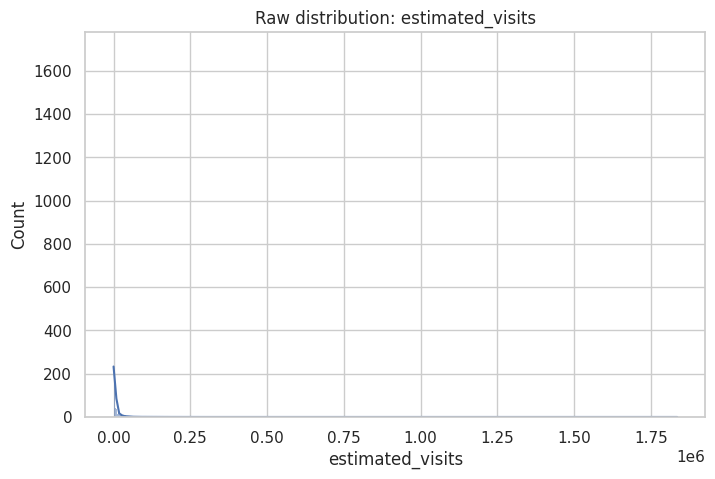

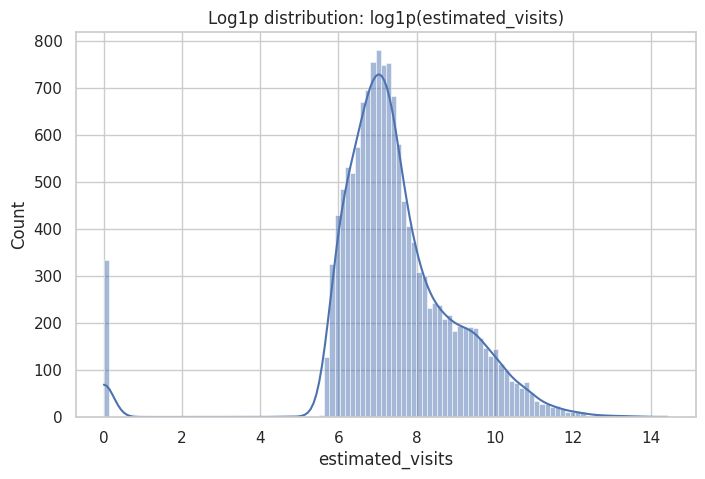

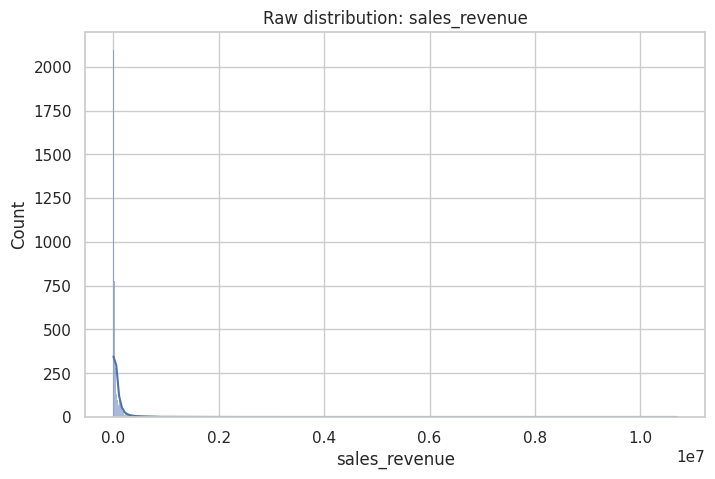

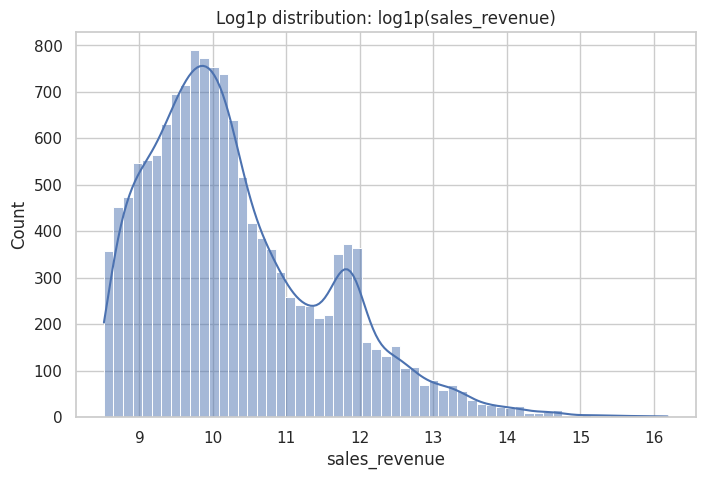

In [47]:
# choose target(s)
target_visits = 'estimated_visits'   # change if different
target_sales = 'sales_revenue'       # change if different

for t in [target_visits, target_sales]:
    if t in df.columns:
        plt.figure()
        sns.histplot(df[t].dropna(), kde=True)
        plt.title(f"Raw distribution: {t}")
        plt.show()

        plt.figure()
        sns.histplot(np.log1p(df[t].dropna()), kde=True)
        plt.title(f"Log1p distribution: log1p({t})")
        plt.show()


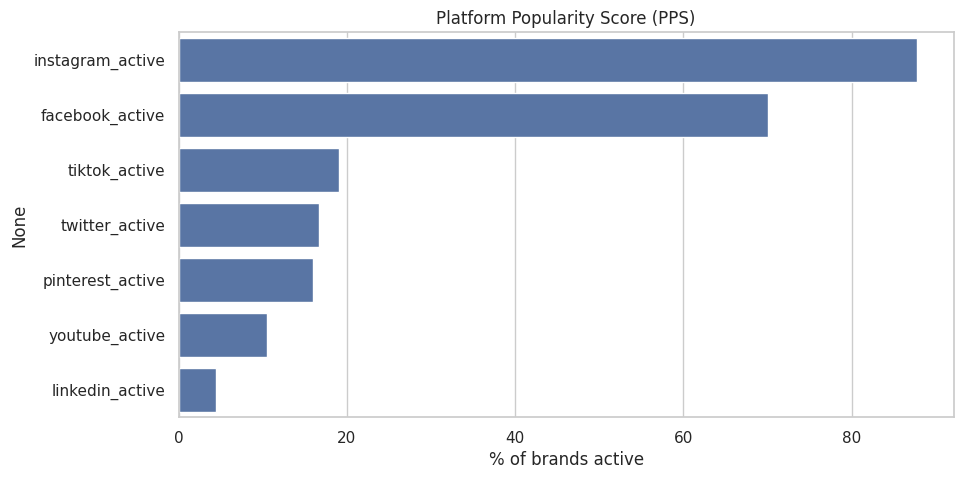

,percent_active
instagram_active,87.716965
facebook_active,70.093785
tiktok_active,19.106943
twitter_active,16.734323
pinterest_active,15.978443
youtube_active,10.561310
linkedin_active,4.416293


In [48]:
active_cols = [c for c in df.columns if c.endswith('_active')]
pps = (df[active_cols].mean() * 100).sort_values(ascending=False)

# barplot
plt.figure(figsize=(10,5))
sns.barplot(x=pps.values, y=pps.index)
plt.xlabel('% of brands active')
plt.title('Platform Popularity Score (PPS)')
plt.show()

# show table
display(pps.to_frame("percent_active"))


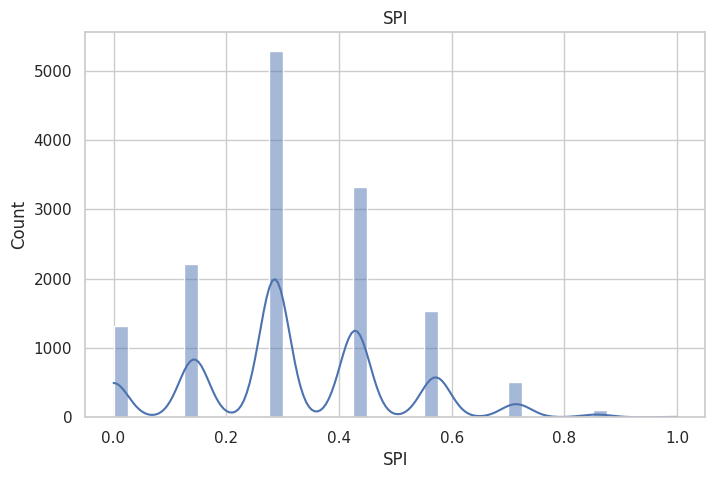

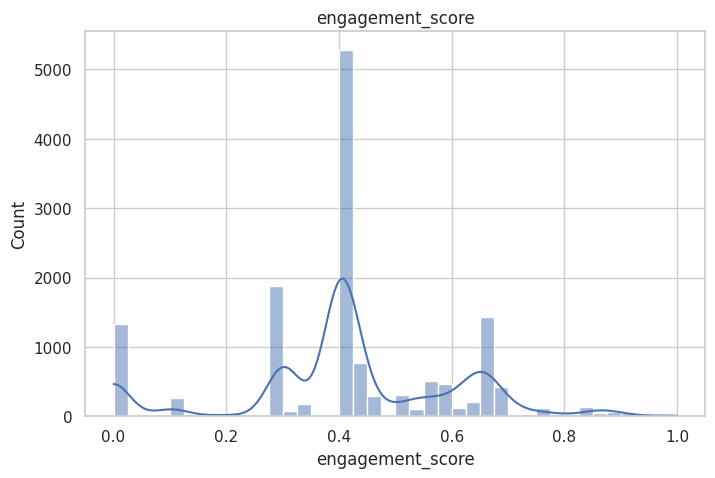

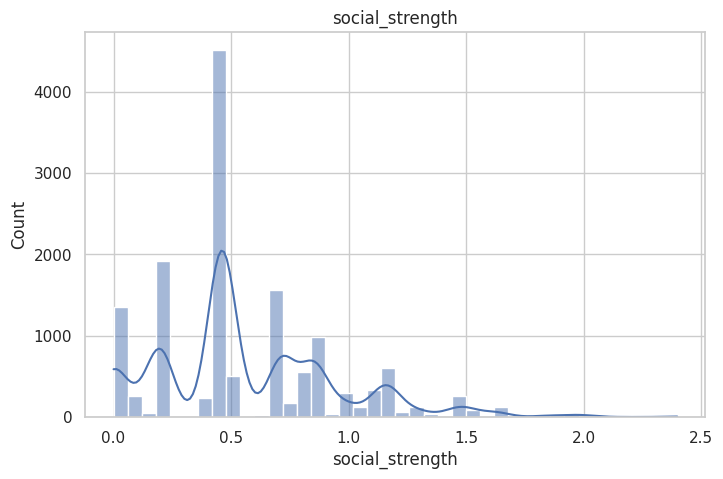

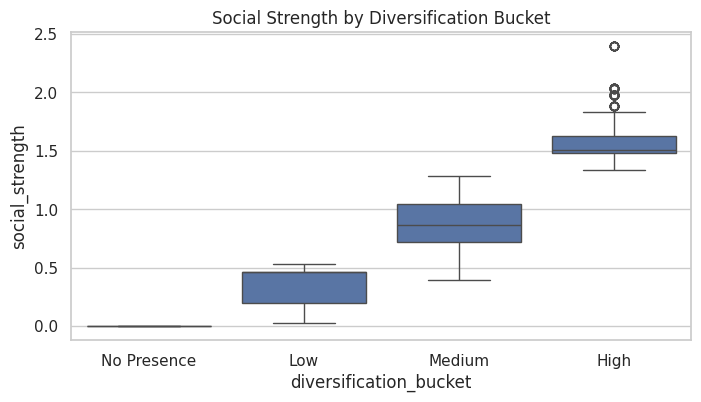

In [49]:
# histograms
for col in ['SPI','engagement_score','social_strength']:
    if col in df.columns:
        plt.figure()
        sns.histplot(df[col].dropna(), kde=True, bins=40)
        plt.title(col)
        plt.show()

# boxplot SPI by diversification_bucket
if 'diversification_bucket' in df.columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='diversification_bucket', y='social_strength', data=df, order=["No Presence","Low","Medium","High"])
    plt.title('Social Strength by Diversification Bucket')
    plt.show()


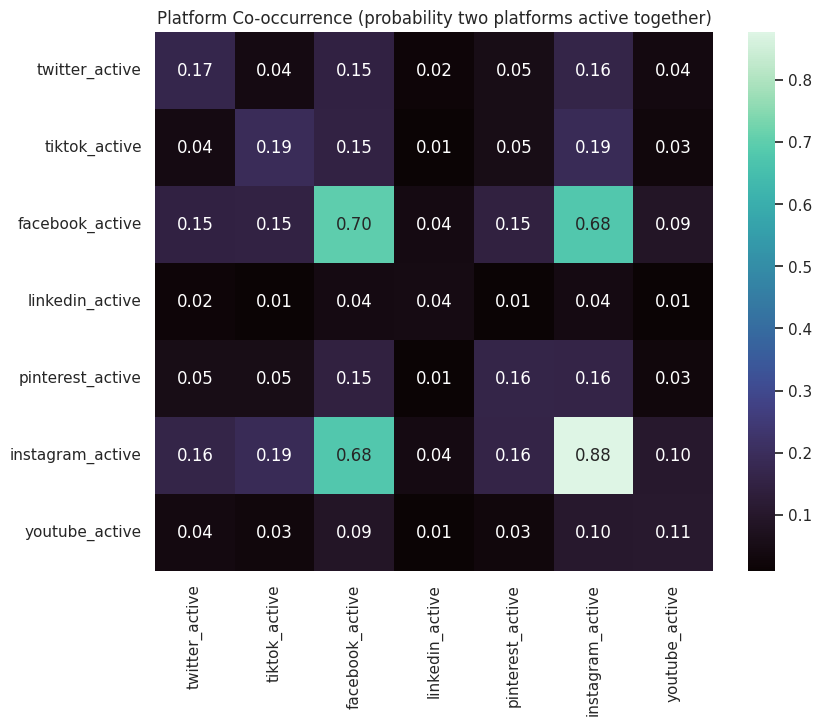

In [51]:
# co-occurrence matrix
co = df[active_cols].T.dot(df[active_cols])
# normalize by number of brands to get co-occurrence probability
co_norm = co / len(df)

# heatmap
plt.figure(figsize=(9,7))
sns.heatmap(co_norm, annot=True, fmt=".2f", cmap="mako")
plt.title("Platform Co-occurrence (probability two platforms active together)")
plt.show()



,spearman_rho,p_value
platform,,
linkedin_active,0.060340,5.254851e-13
youtube_active,0.058973,1.729866e-12
pinterest_active,0.058008,3.945260e-12
instagram_active,0.054894,5.168130e-11
twitter_active,0.050552,1.485787e-09
facebook_active,0.030455,2.717312e-04
tiktok_active,0.016497,4.862102e-02


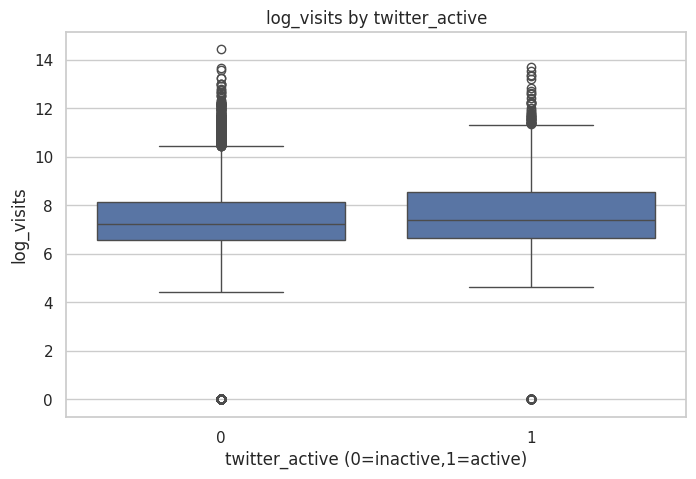

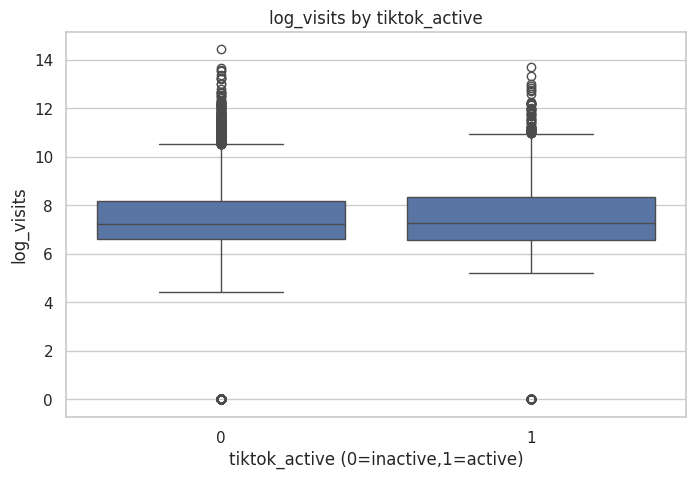

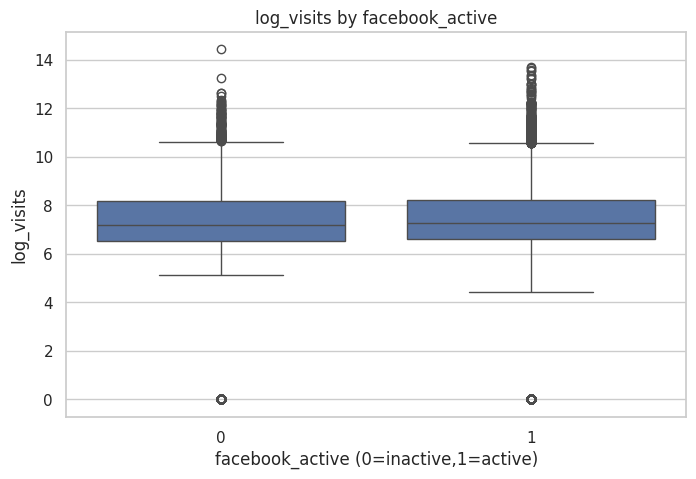

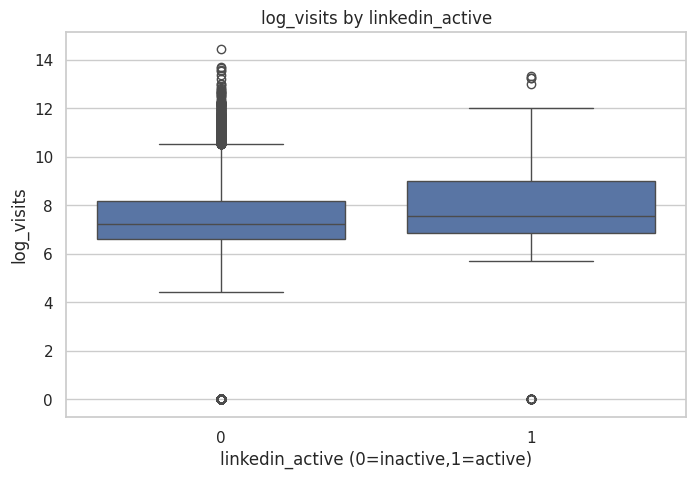

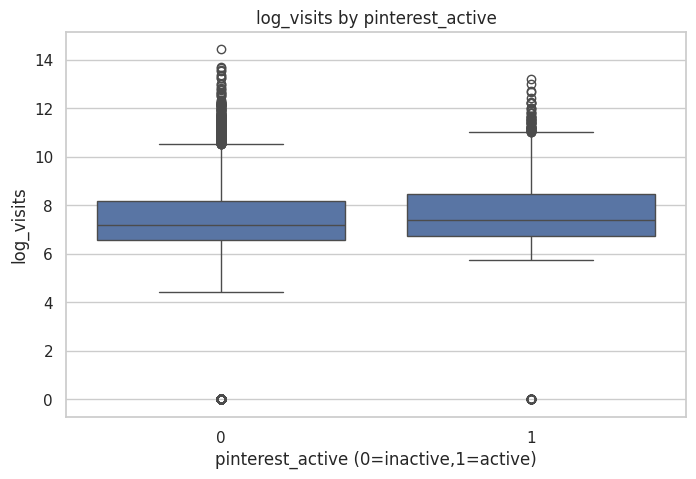

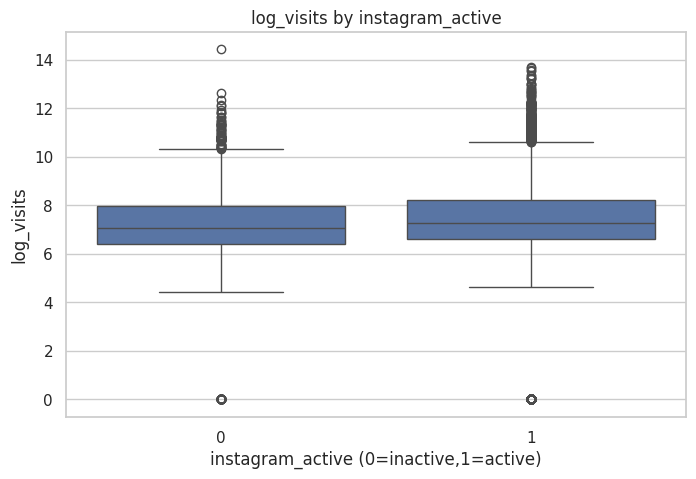

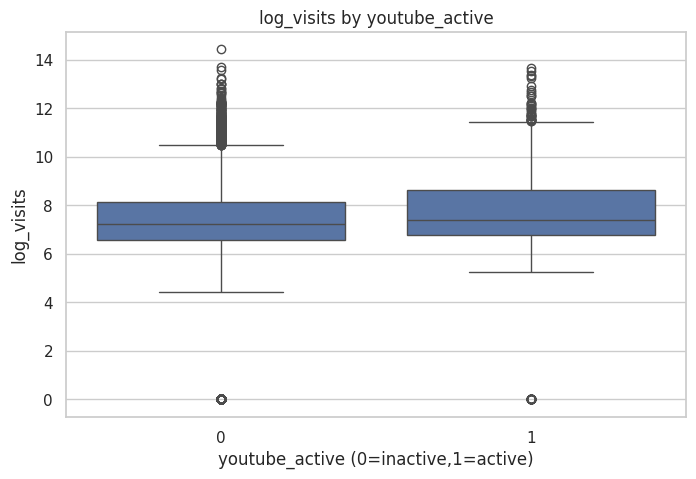

In [52]:
# ensure log targets
if target_visits in df.columns:
    df['log_visits'] = np.log1p(df[target_visits])
if target_sales in df.columns:
    df['log_sales'] = np.log1p(df[target_sales])

# Spearman correlation (robust for binary vs continuous)
corrs = {}
for col in active_cols:
    if 'log_visits' in df.columns:
        rho, p = spearmanr(df[col].fillna(0), df['log_visits'].fillna(0))
        corrs.setdefault('visits', []).append((col, rho, p))
    if 'log_sales' in df.columns:
        rho, p = spearmanr(df[col].fillna(0), df['log_sales'].fillna(0))
        corrs.setdefault('sales', []).append((col, rho, p))

# show sorted correlations with visits
if 'visits' in corrs:
    corrs_vis = sorted(corrs['visits'], key=lambda x: -abs(x[1]))
    display(pd.DataFrame(corrs_vis, columns=['platform','spearman_rho','p_value']).set_index('platform'))

# boxplot platform active vs visits
for col in active_cols:
    if 'log_visits' in df.columns:
        plt.figure()
        sns.boxplot(x=df[col].fillna(0).astype(int), y=df['log_visits'])
        plt.title(f"log_visits by {col}")
        plt.xlabel(col + " (0=inactive,1=active)")
        plt.show()


,SPI_mean,SPI_count,engagement_score_mean,engagement_score_count,social_strength_mean,social_strength_count,log_visits_mean,log_visits_count
country,,,,,,,,
IN,0.322997,1230,0.403049,1230,0.551063,1230,7.820870,1230
US,0.321177,12915,0.416286,12915,0.573219,12915,7.364150,12915
DK,0.274725,143,0.378322,143,0.488497,143,7.512656,143


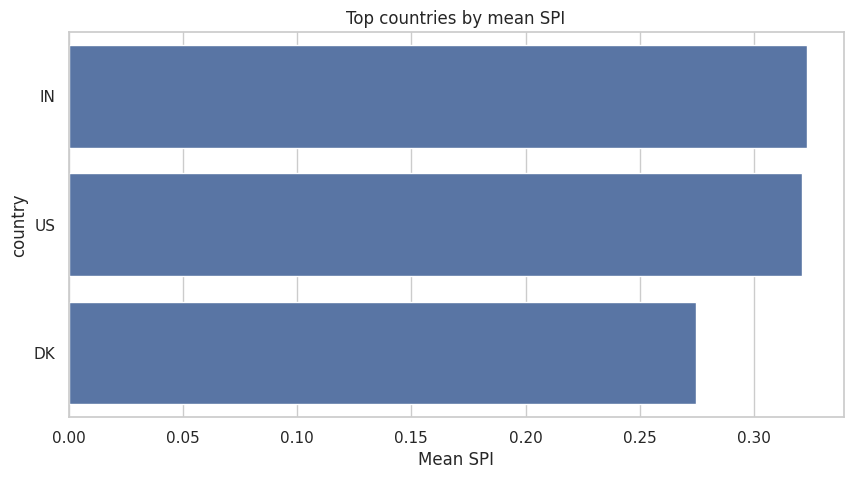

In [55]:
# Country top & bottom by SPI
if 'country' in df.columns:
    c_stats = df.groupby('country')[['SPI','engagement_score','social_strength','log_visits']].agg(['mean','count'])
    c_stats.columns = ['_'.join(c) for c in c_stats.columns]
    c_stats = c_stats.sort_values('SPI_mean', ascending=False)
    display(c_stats.head(10))

    # top countries barplot
    topN = 10
    tmp = c_stats['SPI_mean'].head(topN)
    plt.figure(figsize=(10,5))
    sns.barplot(x=tmp.values, y=tmp.index)
    plt.title("Top countries by mean SPI")
    plt.xlabel("Mean SPI")
    plt.show()


tiktok_active,0,1
instagram_active,,
0,7.052721,6.936234
1,7.254885,7.291315


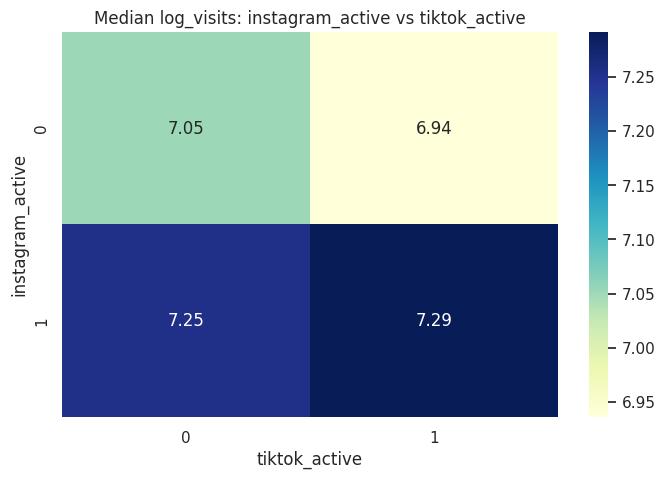

youtube_active,0,1
instagram_active,,
0,7.048386,7.165765
1,7.242798,7.420579


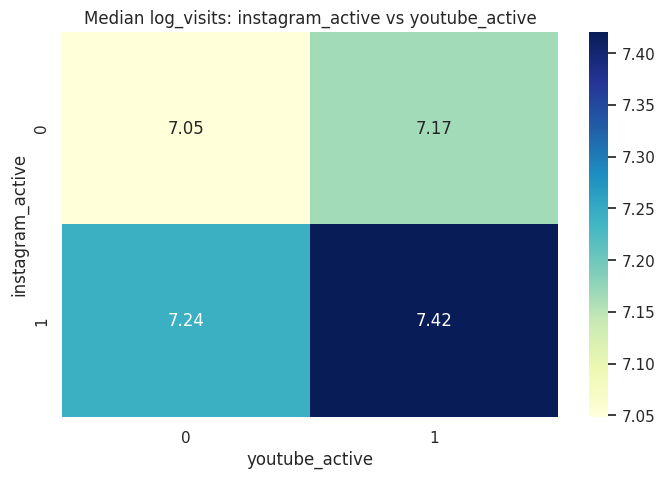

In [56]:
# interaction effect table for instagram and tiktok
pairs = [('instagram_active', 'tiktok_active'), ('instagram_active','youtube_active')]
for a,b in pairs:
    if a in df.columns and b in df.columns and 'log_visits' in df.columns:
        pivot = df.groupby([a,b])['log_visits'].median().unstack()
        display(pivot)
        sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
        plt.title(f"Median log_visits: {a} vs {b}")
        plt.xlabel(b); plt.ylabel(a)
        plt.show()


In [57]:
# clustering on active flags + engagement features
features = active_cols + ['SPI','engagement_score','social_strength']
features = [c for c in features if c in df.columns]
X = df[features].fillna(0)

# scale
scaler = StandardScaler()
X_s = scaler.fit_transform(X)

# try k=2..6, pick best silhouette
best_k = 2
best_score = -1
best_labels = None
for k in range(2,7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_s)
    s = silhouette_score(X_s, labels)
    if s > best_score:
        best_score = s; best_k = k; best_labels = labels

print("Best k:", best_k, "silhouette:", best_score)
df['social_cluster'] = best_labels

# cluster profile
cluster_profile = df.groupby('social_cluster')[features].mean()
display(cluster_profile)


Best k: 6 silhouette: 0.5240387372456781


,twitter_active,tiktok_active,facebook_active,linkedin_active,pinterest_active,instagram_active,youtube_active,SPI,engagement_score,social_strength
social_cluster,,,,,,,,,,
0,0.286655,0.343507,0.949132,0.000000,1.000000,0.995212,0.000000,0.510644,0.507953,0.926027
1,0.035445,0.009878,0.176641,0.002905,0.017432,0.000000,0.029634,0.038848,0.027763,0.029753
2,0.054440,0.157143,0.000000,0.000000,0.030888,1.000000,0.035521,0.182570,0.348641,0.280581
3,0.128528,0.166321,0.992665,0.000000,0.000000,0.998086,0.000000,0.326514,0.444129,0.556957
4,0.464869,0.391767,0.941093,0.000000,0.237757,0.995742,0.853797,0.555004,0.680234,1.144980
5,0.397764,0.218850,0.916933,1.000000,0.266773,0.987220,0.260383,0.578275,0.611917,1.149414


In [58]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# prepare features
X = df[features].fillna(0)
y = df['log_visits'] if 'log_visits' in df.columns else np.log1p(df[target_visits])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear baseline
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("Linear R2:", r2_score(y_test, y_pred), "RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# RF
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("RF R2:", r2_score(y_test, y_pred_rf), "RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

# feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
display(importances.head(20))


Linear R2: 0.004236469068472415 RMSE: 1.677940428797297
RF R2: -0.006280623501724536 RMSE: 1.6867782213042588


,0
social_strength,0.437954
engagement_score,0.165553
linkedin_active,0.081826
pinterest_active,0.069864
twitter_active,0.053503
facebook_active,0.052680
instagram_active,0.039216
SPI,0.036132
tiktok_active,0.032935
youtube_active,0.030337


In [62]:
# Kruskal-Wallis across buckets
if 'diversification_bucket' in df.columns and 'log_visits' in df.columns:
    groups = [df.loc[df['diversification_bucket']==b,'log_visits'].dropna() for b in ["No Presence","Low","Medium","High"] if b in df['diversification_bucket'].unique()]
    stat, p = kruskal(*groups)
    print("Kruskal-Wallis H:", stat, "p:", p)


Kruskal-Wallis H: 98.53921955934634 p: 3.2030748354503365e-21


In [61]:

# small per-company summary
cols_for_summary = ['company','website','country','vertical','active_platform_count','SPI','engagement_score','social_strength','social_cluster','log_visits','log_sales']
available = [c for c in cols_for_summary if c in df.columns]
df[available].to_csv("per_company_social_summary.csv", index=False)


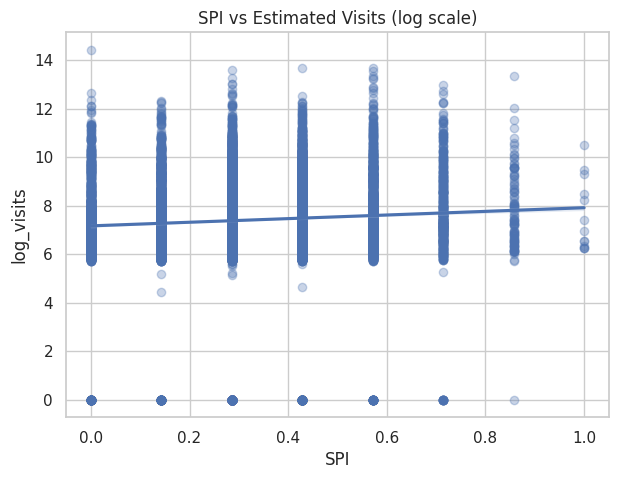

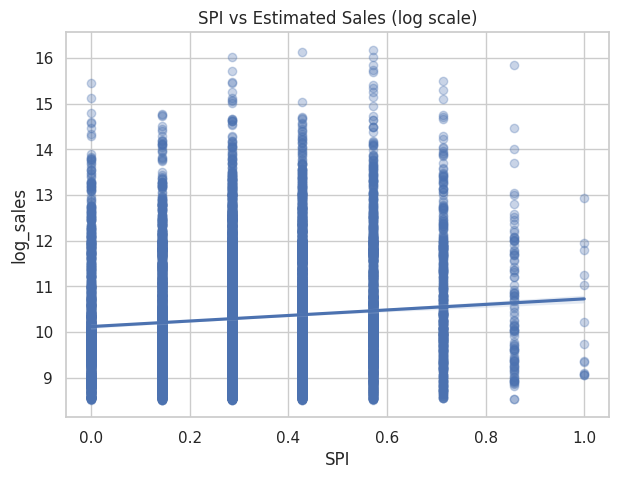

In [63]:
# --- BLOCK A: SPI vs Visits/Sales ---

import seaborn as sns
import matplotlib.pyplot as plt

# Visits
plt.figure(figsize=(7,5))
sns.regplot(x='SPI', y='log_visits', data=df, scatter_kws={'alpha':0.3})
plt.title('SPI vs Estimated Visits (log scale)')
plt.show()

# Sales
plt.figure(figsize=(7,5))
sns.regplot(x='SPI', y='log_sales', data=df, scatter_kws={'alpha':0.3})
plt.title('SPI vs Estimated Sales (log scale)')
plt.show()


In [64]:
print("Spearman (SPI vs log_visits):", df['SPI'].corr(df['log_visits'], method='spearman'))
print("Spearman (SPI vs log_sales):", df['SPI'].corr(df['log_sales'], method='spearman'))


Spearman (SPI vs log_visits): 0.08668882523308521
Spearman (SPI vs log_sales): 0.08911103323053544


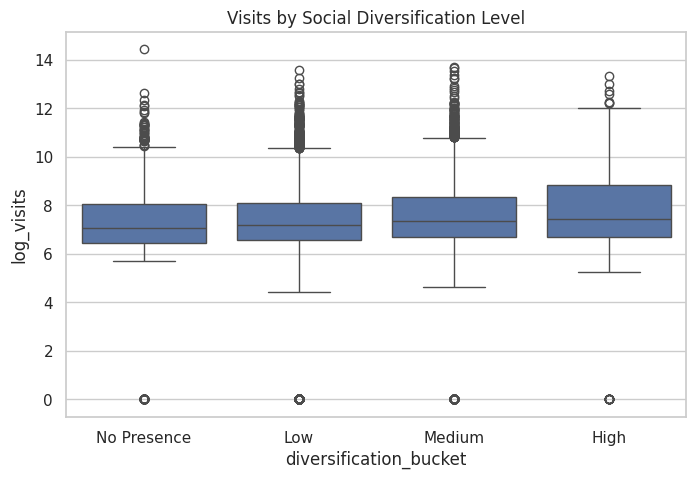

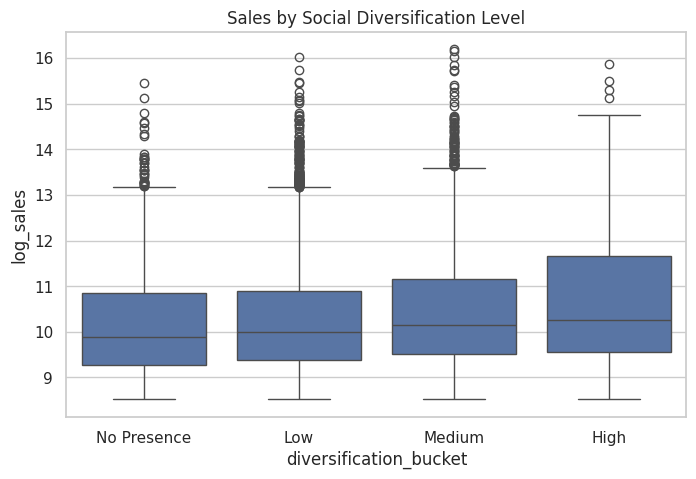

In [65]:
plt.figure(figsize=(8,5))
sns.boxplot(x='diversification_bucket', y='log_visits', data=df,
            order=["No Presence","Low","Medium","High"])
plt.title("Visits by Social Diversification Level")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='diversification_bucket', y='log_sales', data=df,
            order=["No Presence","Low","Medium","High"])
plt.title("Sales by Social Diversification Level")
plt.show()


In [66]:
from scipy.stats import kruskal

groups = [
    df[df['diversification_bucket']=="No Presence"]['log_visits'],
    df[df['diversification_bucket']=="Low"]['log_visits'],
    df[df['diversification_bucket']=="Medium"]['log_visits'],
    df[df['diversification_bucket']=="High"]['log_visits']
]
stat, p = kruskal(*groups)
print("Kruskal-Wallis p-value for visits:", p)


Kruskal-Wallis p-value for visits: 3.2030748354503365e-21


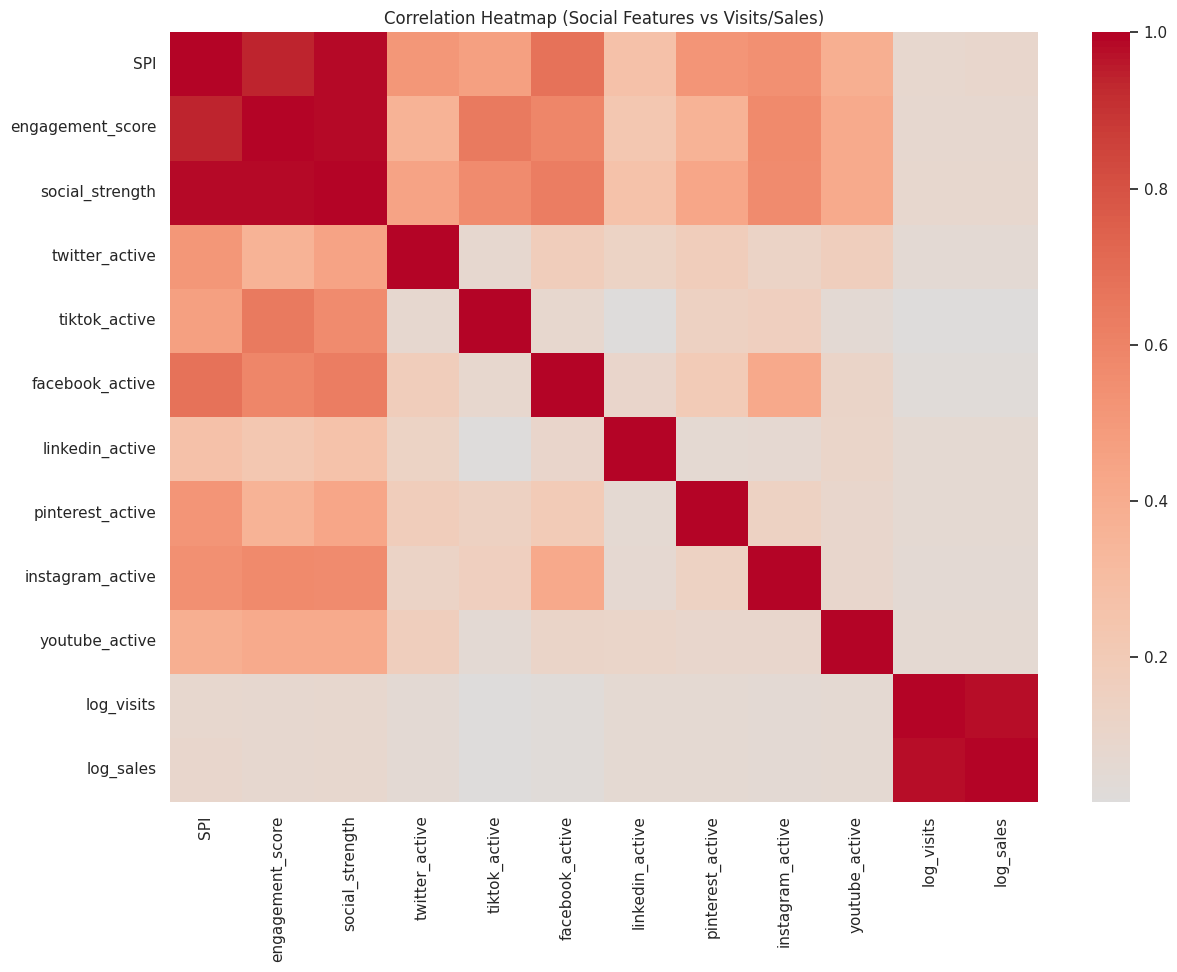

In [67]:
social_features = [
    'SPI','engagement_score','social_strength',
] + [c for c in df.columns if c.endswith('_active')]

corr = df[social_features + ['log_visits','log_sales']].corr(method='spearman')

plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Social Features vs Visits/Sales)')
plt.show()


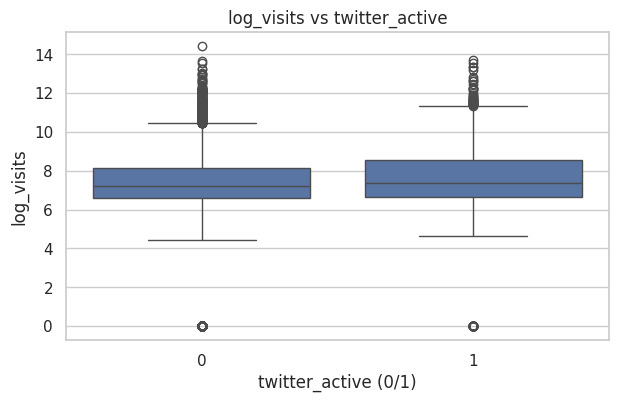

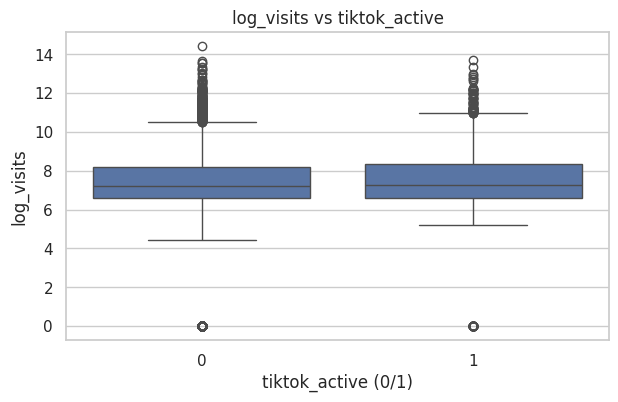

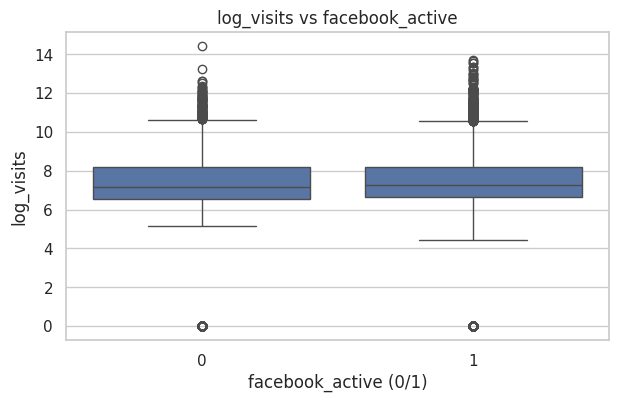

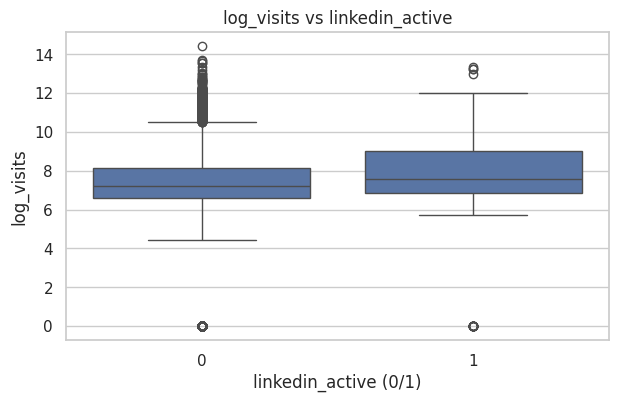

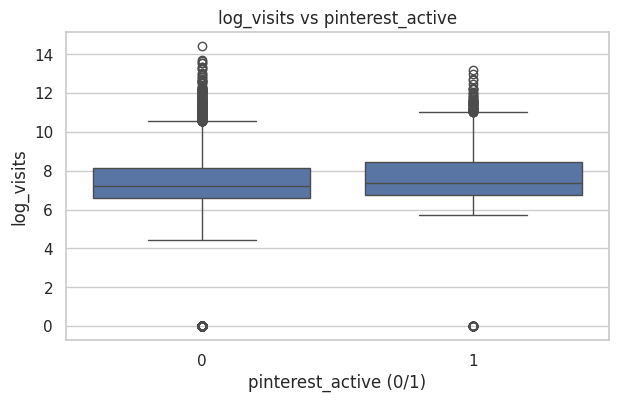

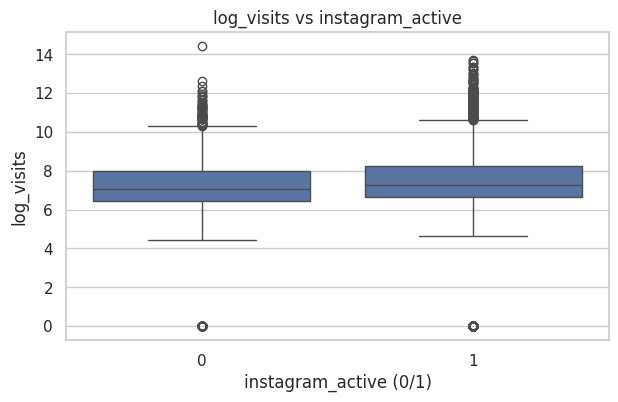

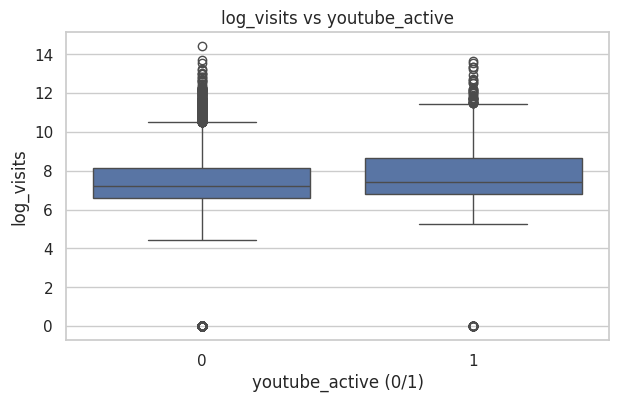

In [68]:
for col in active_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df[col], y=df['log_visits'])
    plt.title(f"log_visits vs {col}")
    plt.xlabel(f"{col} (0/1)")
    plt.show()


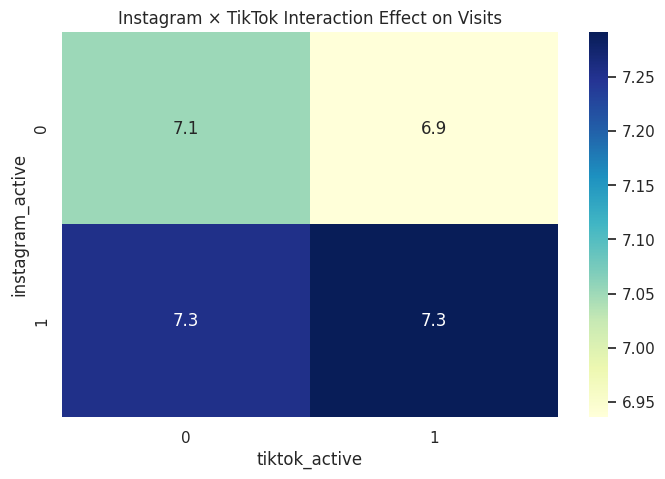

In [69]:
pair = ('instagram_active','tiktok_active')

pivot = df.groupby(list(pair))['log_visits'].median().unstack()
sns.heatmap(pivot, annot=True, cmap="YlGnBu")
plt.title("Instagram × TikTok Interaction Effect on Visits")
plt.show()


In [70]:
# --- WEEK4 BLOCK 1: Prepare features & targets ---
import numpy as np
import pandas as pd

# Target names (these must exist in your df from earlier EDA)
target_visits = 'log_visits'   # log1p(estimated_visits)
target_sales = 'log_sales'     # log1p(sales_revenue)

# Select social-only features (adjust if you have more)
social_active_cols = [c for c in df.columns if c.endswith('_active')]
engineered = ['SPI','engagement_score','social_strength','SPI_norm','engagement_norm','social_strength_norm']
interaction_cols = [c for c in df.columns if '_interaction' in c]
cluster_col = 'social_cluster'  # if exists

# Build feature list (exclude target cols)
features = []
for c in social_active_cols:
    features.append(c)
for c in engineered:
    if c in df.columns:
        features.append(c)
for c in interaction_cols:
    features.append(c)
# one-hot cluster
if cluster_col in df.columns:
    cluster_dummies = pd.get_dummies(df[cluster_col].astype(str), prefix='cluster')
    df = pd.concat([df, cluster_dummies], axis=1)
    features += list(cluster_dummies.columns)

# ensure uniqueness & existence
features = [f for f in dict.fromkeys(features) if f in df.columns]
print("Using features:", features)

# Drop rows with missing target
df_model = df[features + [target_visits, target_sales]].dropna(subset=[target_visits])  # require visits at least
X_social = df_model[features].fillna(0)
y_visits = df_model[target_visits]
y_sales = df_model[target_sales] if target_sales in df_model.columns else None

print("X shape:", X_social.shape, "y_visits shape:", y_visits.shape)


Using features: ['twitter_active', 'tiktok_active', 'facebook_active', 'linkedin_active', 'pinterest_active', 'instagram_active', 'youtube_active', 'SPI', 'engagement_score', 'social_strength', 'SPI_norm', 'engagement_norm', 'social_strength_norm', 'instagram_active_tiktok_active_interaction', 'instagram_active_youtube_active_interaction', 'tiktok_active_youtube_active_interaction', 'instagram_active_linkedin_active_interaction', 'cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5']
X shape: (14288, 23) y_visits shape: (14288,)


In [71]:
# --- WEEK4 BLOCK 2: Split and Baseline Linear Regression ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(X_social, y_visits, test_size=0.2, random_state=42)

# baseline linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

def print_metrics(y_true, y_pred, label="model"):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{label} -> R2: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")

print_metrics(y_test, y_pred_lr, "LinearRegression (baseline)")


LinearRegression (baseline) -> R2: 0.0026 | RMSE: 1.6793 | MAE: 1.1251


In [72]:
# --- WEEK4 BLOCK 3: Random Forest CV and test eval ---
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_params = {
    'n_estimators': [200],
    'max_depth': [6, 10],
    'min_samples_leaf': [3, 7]
}

rf_cv = GridSearchCV(rf, rf_params, cv=5, scoring='r2', n_jobs=-1, verbose=1)
rf_cv.fit(X_train, y_train)

best_rf = rf_cv.best_estimator_
print("RF best params:", rf_cv.best_params_, "best cv R2:", rf_cv.best_score_)

y_pred_rf = best_rf.predict(X_test)
print_metrics(y_test, y_pred_rf, "RandomForest (test)")


Fitting 5 folds for each of 4 candidates, totalling 20 fits
RF best params: {'max_depth': 6, 'min_samples_leaf': 7, 'n_estimators': 200} best cv R2: 0.005229507617274453
RandomForest (test) -> R2: -0.0033 | RMSE: 1.6843 | MAE: 1.1307


In [73]:
# --- WEEK4 BLOCK 4: XGBoost CV and test eval ---
from xgboost import XGBRegressor

xgb = XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=4)

xgb_params = {
    'n_estimators': [200],
    'max_depth': [6,8],
    'learning_rate': [0.05, 0.1]
}

xgb_cv = GridSearchCV(xgb, xgb_params, cv=5, scoring='r2', n_jobs=-1, verbose=1)
xgb_cv.fit(X_train, y_train)

best_xgb = xgb_cv.best_estimator_
print("XGB best params:", xgb_cv.best_params_, "best cv R2:", xgb_cv.best_score_)

y_pred_xgb = best_xgb.predict(X_test)
print_metrics(y_test, y_pred_xgb, "XGBoost (test)")


Fitting 5 folds for each of 4 candidates, totalling 20 fits
XGB best params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200} best cv R2: 0.00015765508595335653
XGBoost (test) -> R2: -0.0042 | RMSE: 1.6851 | MAE: 1.1334


In [74]:
# --- WEEK4 BLOCK 5: K-Fold CV aggregated metrics for best model ---
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
def cv_scores(model, X, y):
    r2 = cross_val_score(model, X, y, cv=kf, scoring='r2', n_jobs=-1)
    return r2.mean(), r2.std()

for name, model in [("RF", best_rf), ("XGB", best_xgb)]:
    mean_r2, std_r2 = cv_scores(model, X_social, y_visits)
    print(f"{name} CV R2: {mean_r2:.4f} ± {std_r2:.4f}")


RF CV R2: 0.0040 ± 0.0041
XGB CV R2: -0.0005 ± 0.0038


Top RF features:


,0
social_strength_norm,0.240869
social_strength,0.238996
engagement_score,0.067389
pinterest_active,0.066119
engagement_norm,0.063736
facebook_active,0.040188
twitter_active,0.038603
instagram_active,0.037410
instagram_active_linkedin_active_interaction,0.026800
cluster_3,0.025208


,0
instagram_active,0.012635
pinterest_active,0.004050
tiktok_active,0.000746
social_strength,0.000469
cluster_0,0.000239
cluster_1,0.000167
SPI_norm,0.000122
cluster_4,0.000102
instagram_active_youtube_active_interaction,0.000033
SPI,0.000007


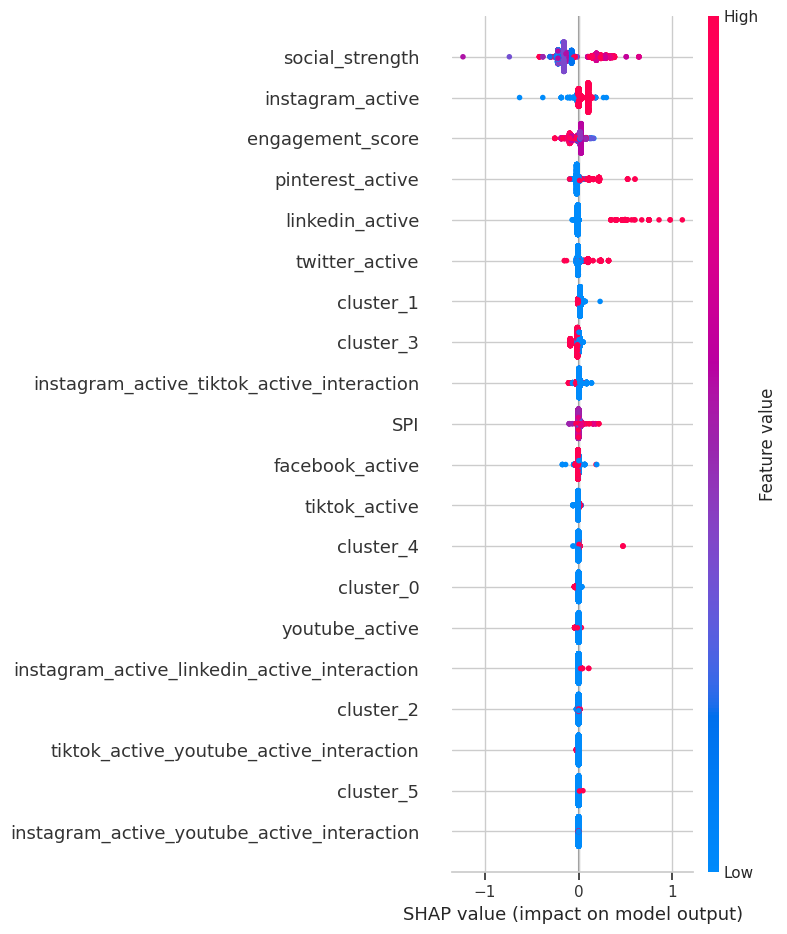

In [75]:
# --- WEEK4 BLOCK 6: Feature importance & SHAP (for best model) ---
import joblib
import pandas as pd
# feature importance (RF or XGB)
fi = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Top RF features:")
display(fi.head(20))
fi.to_csv("social_feature_importances_rf.csv", index=True)

# Permutation importance (alternative)
from sklearn.inspection import permutation_importance
perm = permutation_importance(best_rf, X_test, y_test, n_repeats=20, random_state=42, n_jobs=-1)
perm_df = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
display(perm_df.head(20))

# SHAP (use best_xgb.model if using xgboost; else use tree explainer on RF)
import shap
# prepare explainer on pre-fit model
if 'XGBRegressor' in type(best_xgb).__name__:
    explainer = shap.Explainer(best_xgb)
    shap_values = explainer(X_test)
else:
    explainer = shap.TreeExplainer(best_rf)
    shap_values = explainer.shap_values(X_test)

# SHAP summary plot
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('shap_summary_social.png', dpi=150)
plt.show()


In [76]:
# --- WEEK4 BLOCK 7: Ablation study ---
groups = {
    'all': features,
    'no_spi': [f for f in features if f not in ['SPI','SPI_norm']],
    'no_engagement': [f for f in features if f not in ['engagement_score','engagement_norm']],
    'no_interactions': [f for f in features if '_interaction' not in f],
    'only_engagement': [f for f in features if f in ['engagement_score','engagement_norm','social_strength','social_strength_norm']]
}

ablation_results = {}
from sklearn.model_selection import cross_val_score
for name, cols in groups.items():
    X_tmp = X_social[cols]
    model = XGBRegressor(objective='reg:squarederror', n_estimators=200, random_state=42, n_jobs=4)
    scores = cross_val_score(model, X_tmp, y_visits, cv=5, scoring='r2', n_jobs=-1)
    ablation_results[name] = (scores.mean(), scores.std())

pd.DataFrame.from_dict(ablation_results, orient='index', columns=['mean_r2','std_r2']).sort_values('mean_r2', ascending=False)


,mean_r2,std_r2
only_engagement,-0.011426,0.019392
no_interactions,-0.013076,0.018665
all,-0.013167,0.018716
no_spi,-0.013178,0.018677
no_engagement,-0.013462,0.018870


In [77]:
# --- WEEK4 BLOCK 8: Save model and predictions ---
joblib.dump(best_xgb, 'final_social_xgb.joblib')

# Predictions for all companies (use X_social aligned)
preds = best_xgb.predict(X_social)
df_model['pred_log_visits_social'] = preds
df_model['pred_visits_social'] = np.expm1(preds)  # inverse of log1p

# Save per-company summary
cols_out = ['company','website','country','vertical','SPI','engagement_score','social_strength','pred_log_visits_social','pred_visits_social']
available = [c for c in cols_out if c in df_model.columns]
df_model[available].to_csv('per_company_social_model_predictions.csv', index=False)


In [78]:
# --- Prepare target for log_sales ---
df_model_sales = df_model.dropna(subset=['log_sales'])
X_sales = df_model_sales[features].fillna(0)
y_sales = df_model_sales['log_sales']

print("X_sales shape:", X_sales.shape)
print("y_sales shape:", y_sales.shape)


X_sales shape: (14288, 23)
y_sales shape: (14288,)


In [79]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sales, y_sales, test_size=0.2, random_state=42
)

lr_s = LinearRegression()
lr_s.fit(X_train_s, y_train_s)
y_pred_lr_s = lr_s.predict(X_test_s)

print("Baseline Linear Model (Sales)")
print_metrics(y_test_s, y_pred_lr_s, "LinearRegression_sales")


Baseline Linear Model (Sales)
LinearRegression_sales -> R2: 0.0065 | RMSE: 1.2189 | MAE: 0.9675


In [80]:
rf_cv_s = GridSearchCV(
    rf, rf_params, cv=5, scoring='r2', n_jobs=-1, verbose=1
)
rf_cv_s.fit(X_train_s, y_train_s)

best_rf_s = rf_cv_s.best_estimator_
print("RF best params (sales):", rf_cv_s.best_params_, "CV R2:", rf_cv_s.best_score_)

y_pred_rf_s = best_rf_s.predict(X_test_s)
print_metrics(y_test_s, y_pred_rf_s, "RandomForest_sales")


Fitting 5 folds for each of 4 candidates, totalling 20 fits
RF best params (sales): {'max_depth': 6, 'min_samples_leaf': 7, 'n_estimators': 200} CV R2: 0.01002426655189439
RandomForest_sales -> R2: 0.0028 | RMSE: 1.2212 | MAE: 0.9695


In [81]:
xgb_cv_s = GridSearchCV(
    xgb, xgb_params, cv=5, scoring='r2', n_jobs=-1, verbose=1
)
xgb_cv_s.fit(X_train_s, y_train_s)

best_xgb_s = xgb_cv_s.best_estimator_
print("XGB best params (sales):", xgb_cv_s.best_params_, "CV R2:", xgb_cv_s.best_score_)

y_pred_xgb_s = best_xgb_s.predict(X_test_s)
print_metrics(y_test_s, y_pred_xgb_s, "XGB_sales")


Fitting 5 folds for each of 4 candidates, totalling 20 fits
XGB best params (sales): {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 200} CV R2: 0.003796087435635176
XGB_sales -> R2: 0.0004 | RMSE: 1.2226 | MAE: 0.9711


In [82]:
ablation_results_sales = {}

for name, cols in groups.items():
    X_tmp = X_sales[cols]
    model = XGBRegressor(objective='reg:squarederror', n_estimators=200, random_state=42)
    scores = cross_val_score(model, X_tmp, y_sales, cv=5, scoring='r2', n_jobs=-1)
    ablation_results_sales[name] = (scores.mean(), scores.std())

pd.DataFrame.from_dict(ablation_results_sales, orient='index', columns=['mean_r2','std_r2'])


,mean_r2,std_r2
all,-0.011621,0.016643
no_spi,-0.011578,0.016585
no_engagement,-0.011557,0.016493
no_interactions,-0.011627,0.016514
only_engagement,-0.008356,0.017635


In [85]:
joblib.dump(best_xgb_s, 'final_social_xgb_sales.joblib')

# Generate predictions for the entire X_sales dataset
full_predictions_sales = best_xgb_s.predict(X_sales)
df_model_sales['pred_log_sales_social'] = full_predictions_sales
df_model_sales['pred_sales_social'] = np.expm1(full_predictions_sales)

cols_out_s = ['company','country','vertical','SPI','engagement_score','social_strength','pred_sales_social']
avail_s = [c for c in cols_out_s if c in df_model_sales.columns]
df_model_sales[avail_s].to_csv("per_company_social_model_predictions_sales.csv", index=False)

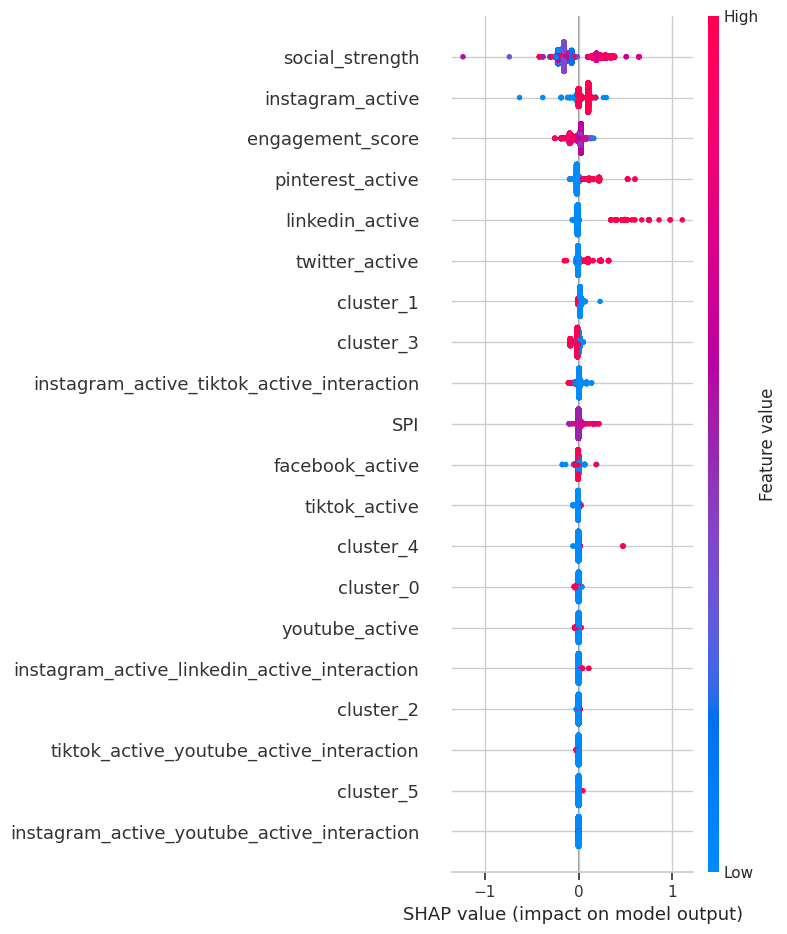

In [86]:
# --- WEEK5 BLOCK 1: SHAP Summary (Visits Model) ---
import shap

# For XGB model
explainer_vis = shap.Explainer(best_xgb)
shap_values_vis = explainer_vis(X_test)

# Summary bar plot
shap.summary_plot(shap_values_vis, X_test, show=False)
plt.tight_layout()
plt.savefig("shap_summary_visits.png", dpi=150)
plt.show()


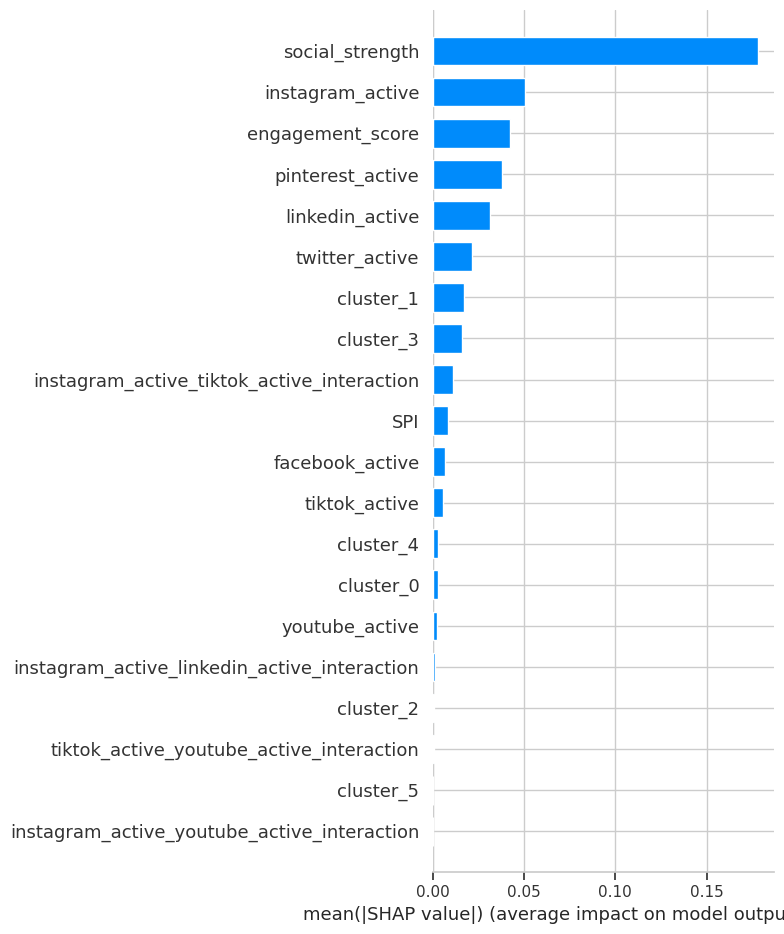

In [87]:
# --- WEEK5 BLOCK 2: SHAP Bar Plot (Visits Model) ---
shap.summary_plot(shap_values_vis, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("shap_bar_visits.png", dpi=150)
plt.show()


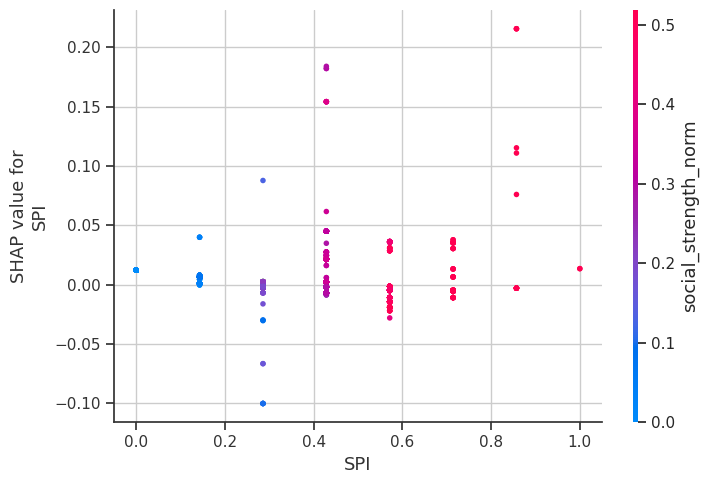

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


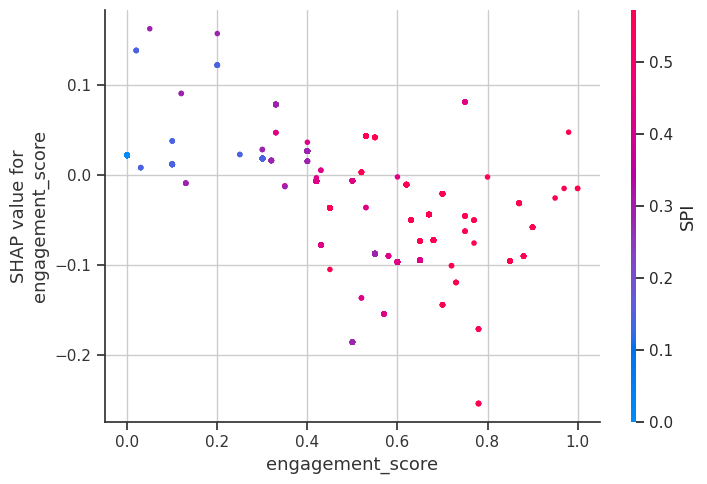

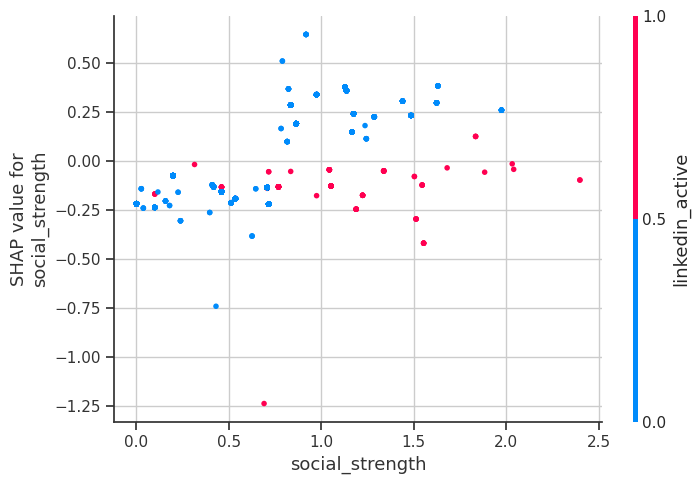

In [88]:
# --- WEEK5 BLOCK 3: Dependence (SPI, engagement, social_strength) ---

for feature in ['SPI', 'engagement_score', 'social_strength']:
    if feature in X_test.columns:
        shap.dependence_plot(
            feature, shap_values_vis.values, X_test, show=False
        )
        plt.tight_layout()
        plt.savefig(f"shap_dependence_{feature}.png", dpi=150)
        plt.show()


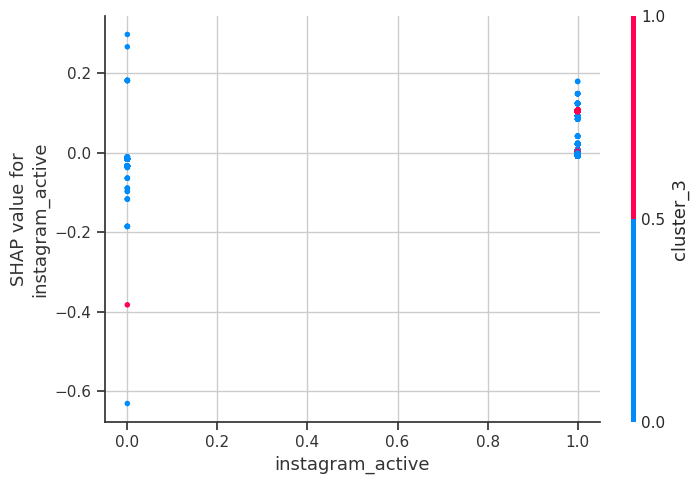

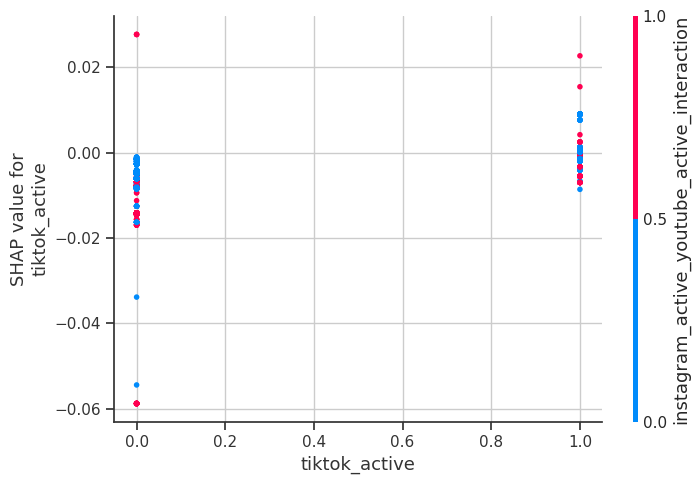

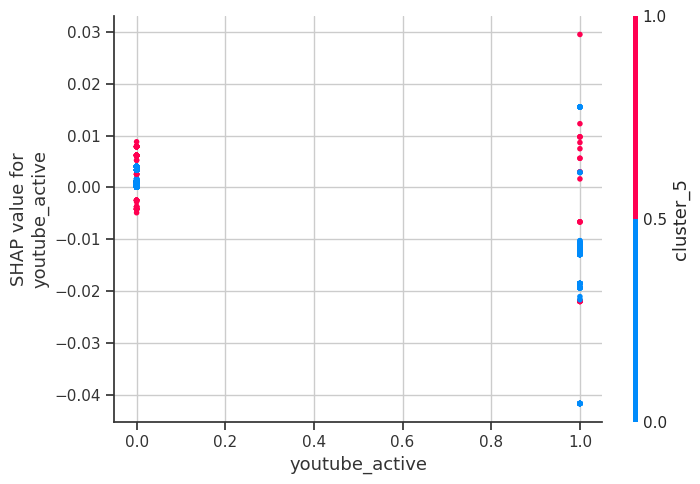

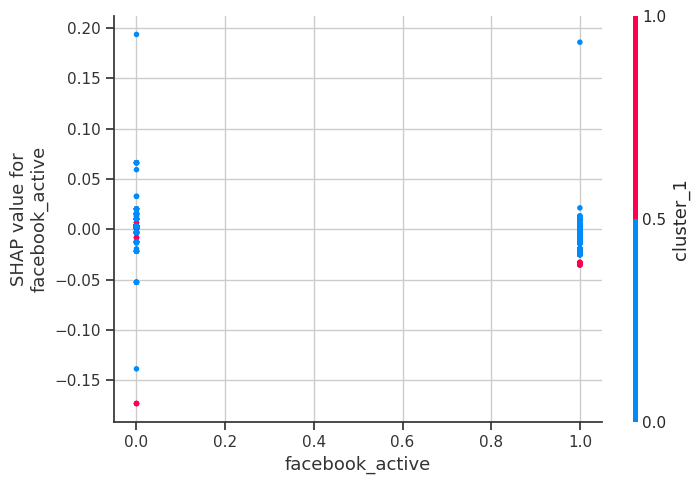

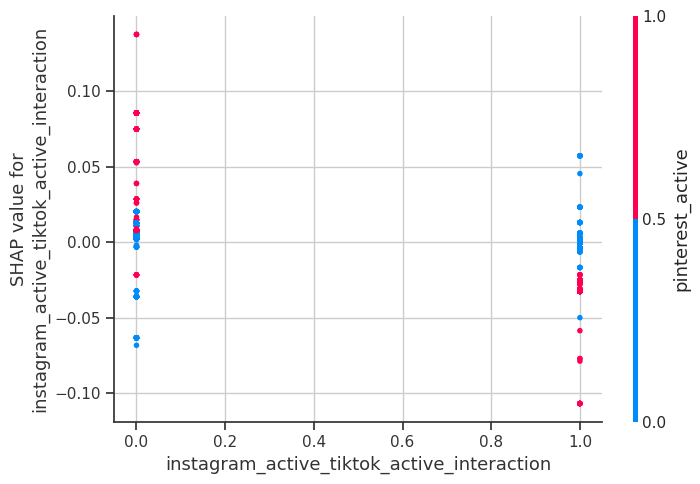

In [89]:
# --- WEEK5 BLOCK 4: Dependence for platform features ---
platform_features = [
    'instagram_active', 'tiktok_active',
    'youtube_active', 'facebook_active',
    'instagram_active_tiktok_active_interaction'
]

for feature in platform_features:
    if feature in X_test.columns:
        shap.dependence_plot(
            feature, shap_values_vis.values, X_test, show=False
        )
        plt.tight_layout()
        plt.savefig(f"shap_dependence_{feature}.png", dpi=150)
        plt.show()


In [90]:
# --- WEEK5 BLOCK 6: SHAP Feature Importance Table ---

mean_abs_shap = np.abs(shap_values_vis.values).mean(axis=0)
shap_df = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

shap_df.to_csv("shap_feature_importance_visits.csv", index=False)
display(shap_df.head(20))


,feature,mean_abs_shap
9,social_strength,0.177903
5,instagram_active,0.050630
8,engagement_score,0.042200
4,pinterest_active,0.037973
3,linkedin_active,0.031428
0,twitter_active,0.021580
18,cluster_1,0.016963
20,cluster_3,0.016208
13,instagram_active_tiktok_active_interaction,0.011400
7,SPI,0.008238


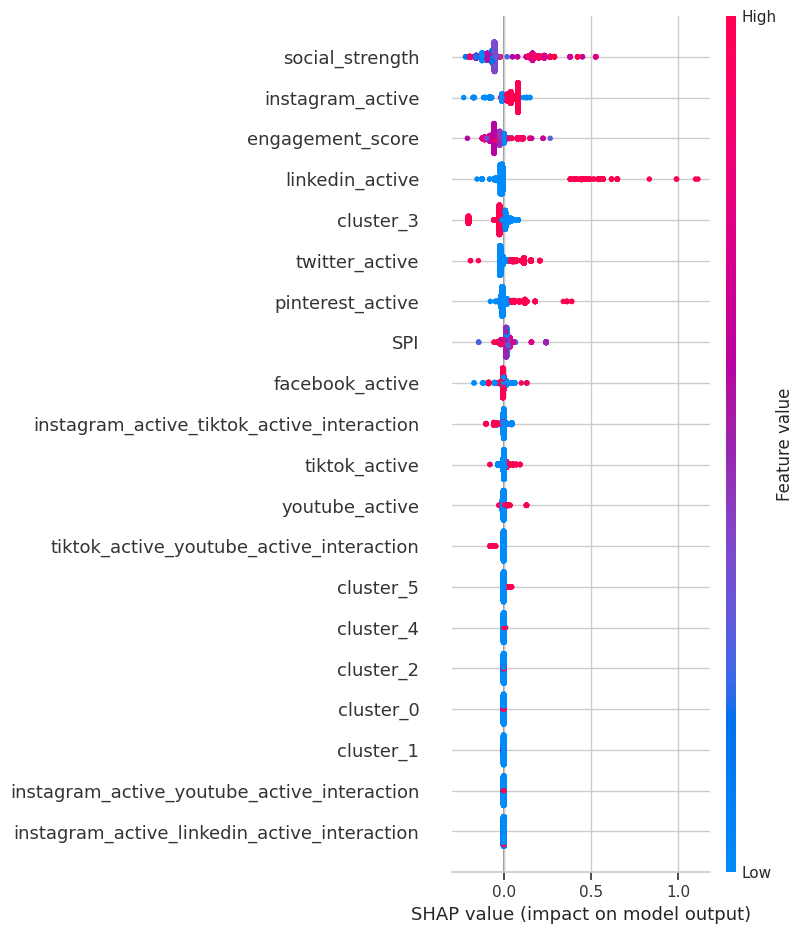

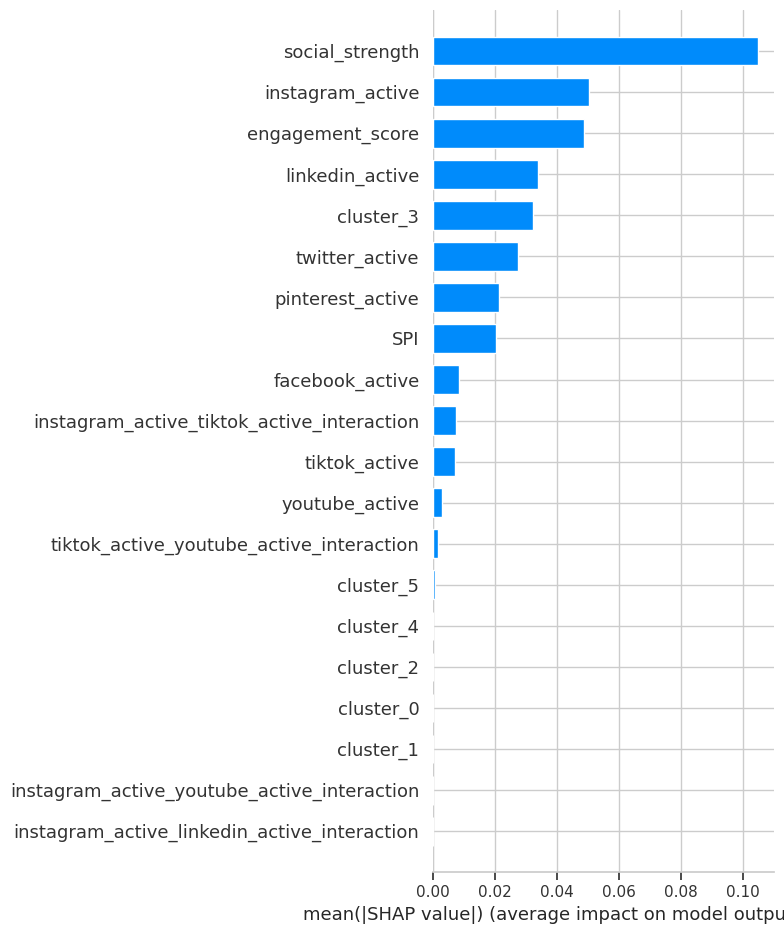

In [91]:
# --- WEEK5 BLOCK 7: SHAP for Sales Model ---
explainer_sales = shap.Explainer(best_xgb_s)
shap_values_sales = explainer_sales(X_test_s)

shap.summary_plot(shap_values_sales, X_test_s, show=False)
plt.savefig("shap_summary_sales.png", dpi=150)
plt.show()

shap.summary_plot(shap_values_sales, X_test_s, plot_type="bar", show=False)
plt.savefig("shap_bar_sales.png", dpi=150)
plt.show()
